In [6]:
from datetime import date, timedelta
from functools import partial
from pathlib import Path
from typing import Dict
from math import exp

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from okx.store import OrderbookStore
from okx.recipes.forwards import build_forwards_kalman, prepare_pillars
from forwards import (
    load_matched_options,
    compute_option_parity_table,
    summarize_option_parity,
    evaluate_curve_snapshot,
    loeo_error,
)
from forwards.parity import compute_option_parity_table, summarize_option_parity
from forwards.kalman_ns import NSCarryState, reconstruct_ns_forward

In [7]:
store = OrderbookStore(
    data_root="data/okx",
    manifest_path="data/okx/manifest.sqlite",
    batch_days=3,
)

In [8]:
start = date(2025, 9, 1)
end = date(2025, 10, 1)
dates = [start + timedelta(days=i) for i in range((end - start).days)]
inst_family = "BTC-USD"
binning = '30s'
min_time_to_expiry_hours = 2.0
min_moneyness = exp(-0.05)
max_moneyness = exp(0.05)

In [9]:
df_options = load_matched_options(
    store=store,
    dates=dates,
    inst_family=inst_family,
    forwards_recipe=build_forwards_kalman,
    binning=binning,
    min_time_to_expiry_hours=min_time_to_expiry_hours,
    verbose=True,
)
df_parity = compute_option_parity_table(
    df_options,
    min_moneyness=min_moneyness,
    max_moneyness=max_moneyness,
)

Processing batches:   0%|          | 0/10 [00:00<?, ?it/s]

[store] Applying transforms for BTC-USD/OPTION (depth=1, binning=30s, features=['trim', 'strip', 'bin', <function finalize_binning at 0x310036fc0>, 'tenor', <function early_roll.<locals>.filter_fn at 0x3b8c16840>, 'parse_option'])
  - applied 'trim'
  - applied 'strip'
  - applied 'bin'
  - applied 'finalize_binning'
  - applied 'tenor'
  - applied 'filter_fn'
  - applied 'parse_option'
[store] Applying transforms for BTC-USD/OPTION (depth=1, binning=30s, features=['trim', 'strip', 'bin', <function finalize_binning at 0x310036fc0>, 'tenor', <function early_roll.<locals>.filter_fn at 0x3b8c16840>, 'parse_option'])
  - applied 'trim'
  - applied 'strip'
  - applied 'bin'
  - applied 'finalize_binning'
  - applied 'tenor'
  - applied 'filter_fn'
  - applied 'parse_option'
[store] Applying transforms for BTC-USD/OPTION (depth=1, binning=30s, features=['trim', 'strip', 'bin', <function finalize_binning at 0x310036fc0>, 'tenor', <function early_roll.<locals>.filter_fn at 0x3b8c16840>, 'parse

Processing batches:   0%|          | 0/10 [00:00<?, ?it/s]

Time taken to prepare pillars: 0:00:01.989160
Time taken to build snapshots: 0:00:00.047961 (8,639 usable timestamps)


Kalman filter:   0%|          | 0/8639 [00:00<?, ?it/s]

...

Time taken to run Kalman filter: 0:00:00.421026
Time taken to convert states: 0:00:00.001826
Time taken to prepare pillars: 0:00:01.494279
Time taken to build snapshots: 0:00:00.046862 (8,639 usable timestamps)


Kalman filter:   0%|          | 0/8639 [00:00<?, ?it/s]

Time taken to run Kalman filter: 0:00:00.428915
Time taken to convert states: 0:00:00.001335
Time taken to fetch forwards: 0:00:20.604920
Time taken to build forward lookup: 0:00:00.309411


Matching forwards to options: 100%|██████████| 86390/86390 [00:04<00:00, 21404.26it/s]


Time taken to match forwards to options: core 0:00:05.985969, incl. setup 0:00:05.986090 (matched 32,743,307 / 32,743,307 options)


In [31]:
df_parity = df_parity.with_columns([
    ((pl.col('call_ask_1_px') - pl.col('call_bid_1_px')) / ((pl.col('call_ask_1_px') + pl.col('call_bid_1_px')) / 2)).alias('call_rel_spread'),
    ((pl.col('put_ask_1_px') - pl.col('put_bid_1_px')) / ((pl.col('put_ask_1_px') + pl.col('put_bid_1_px')) / 2)).alias('put_rel_spread')
])

In [41]:
df_parity = df_parity.with_columns([
    ((pl.col('call_bid_1_px') + pl.col('call_ask_1_px')) / (pl.col('F_implied_mid') - pl.col('strike'))).alias('call_weight'),
    ((pl.col('put_bid_1_px') + pl.col('put_ask_1_px')) / (pl.col('F_implied_mid') - pl.col('strike'))).alias('put_weight')
])

In [40]:
print(f"df_parity memory usage: {df_parity.estimated_size('mb'):.2f} MB")


df_parity memory usage: 1151.10 MB


In [ ]:
def plot_parity_results(df, BIN_MINS=5, name="Kalman forwards"):
    time_bin_col = (pl.col('timeMs') // (60_000 * BIN_MINS) * (60_000 * BIN_MINS)).cast(pl.Int64).alias('time_bin')
    df_bin = (
        df.with_columns([time_bin_col])
        .group_by(['time_bin'])
        .agg([
            pl.mean('error_mid_bps').alias('mean_error_mid_bps'),
            pl.std('error_mid_bps').alias('std_error_mid_bps'),
            pl.quantile('error_mid_bps', 0.05).alias('q05_error_mid_bps'),
            pl.median('error_mid_bps').alias('median_error_mid_bps'),
            pl.quantile('error_mid_bps', 0.95).alias('q95_error_mid_bps'),
            pl.len().alias('count'),
        ])
        .sort(['time_bin'])
        .to_pandas()
    )
    # Convert ms to datetime
    df_bin['datetime'] = pd.to_datetime(df_bin['time_bin'], unit='ms')

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(df_bin['datetime'], df_bin['mean_error_mid_bps'], label='Mean')
    ax.plot(df_bin['datetime'], df_bin['median_error_mid_bps'], label='Median', alpha=0.6)
    ax.fill_between(
        df_bin['datetime'],
        df_bin['q05_error_mid_bps'],
        df_bin['q95_error_mid_bps'],
        color='blue', alpha=0.2, label='5-95% Quantile'
    )
    ax.set_title(f"{name} error_mid_bps by TIME ({BIN_MINS} min bins)")
    ax.set_xlabel("Time")
    ax.set_ylabel("error_mid_bps")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    


=== tenor in [0.0009, 1.0355], moneyness in [0.9512, 0.9846) ===


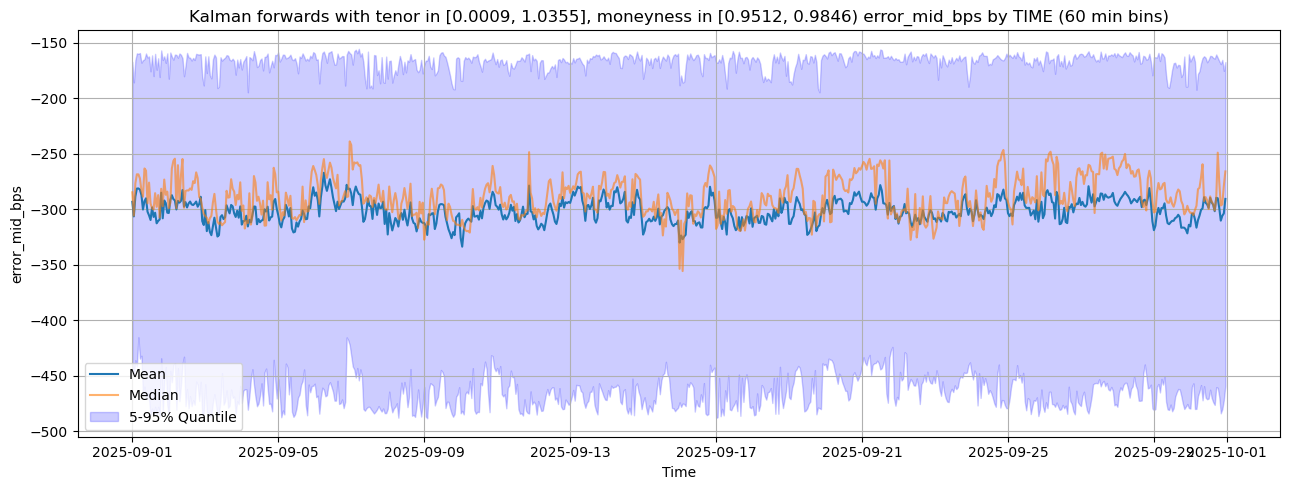


=== tenor in [0.0009, 1.0355], moneyness in [0.9846, 1.0179) ===


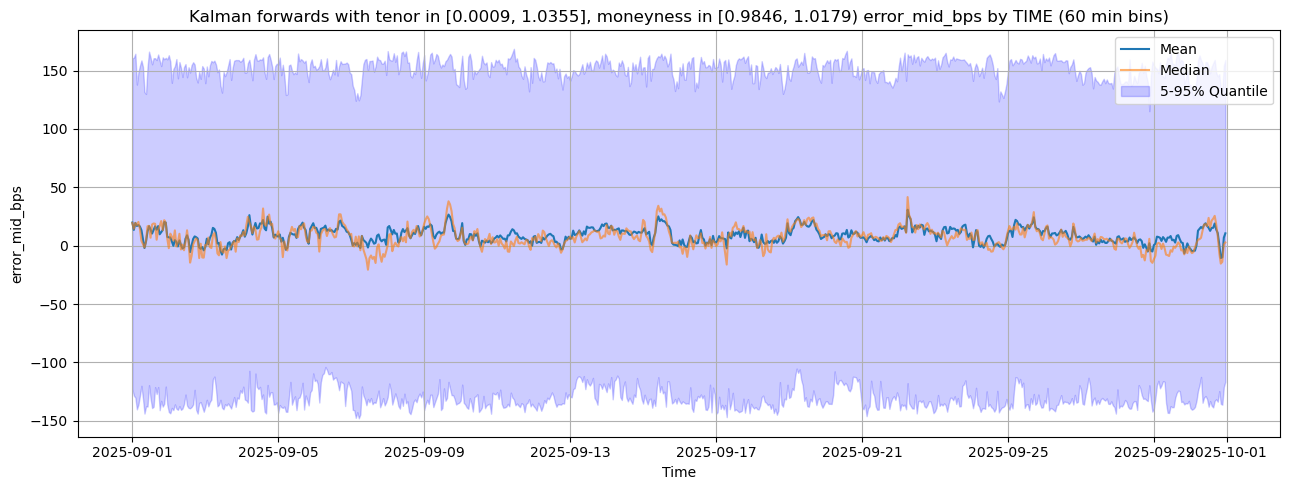


=== tenor in [0.0009, 1.0355], moneyness in [1.0179, 1.0513] ===


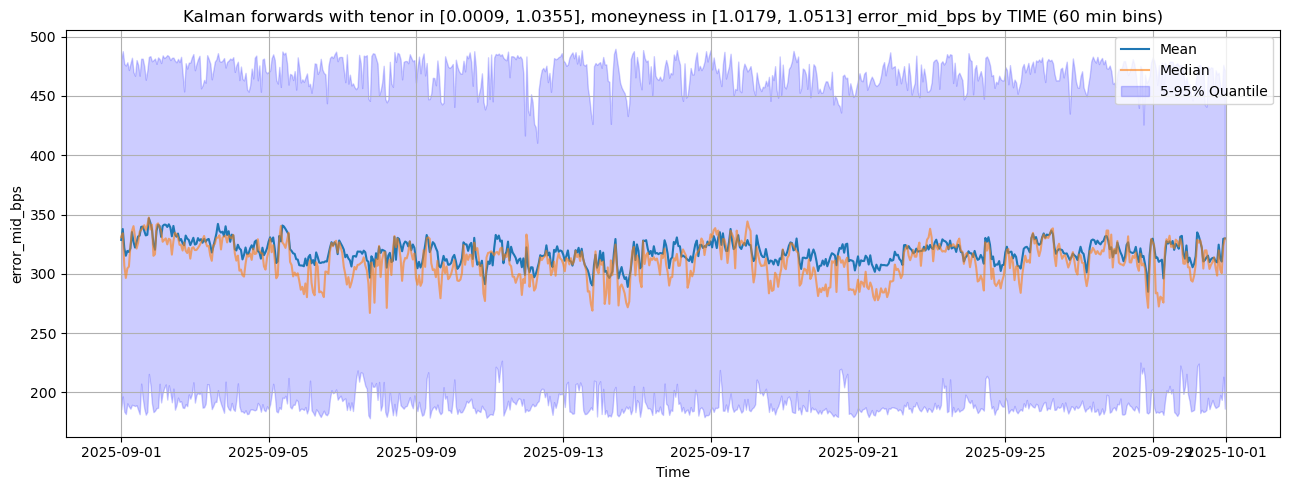

In [43]:
# Define moneyness bins using min_moneyness and max_moneyness
num_moneyness_bins = 3
moneyness_bins = np.linspace(min_moneyness, max_moneyness, num_moneyness_bins + 1)

BIN_MINS = 60

import numpy as np

num_tenor_bins = 1
# Bin by actual tenor quantiles for equal-size bins
tenor_values = df_parity['T'].to_numpy()
tenor_bins = np.quantile(tenor_values, np.linspace(0, 1, num_tenor_bins + 1))

# Create all bin edges as ranges
bin_grid = [
    (
        i,  # tenor bin index
        tenor_bins[i],
        tenor_bins[i + 1],
        j,  # moneyness bin index
        moneyness_bins[j],
        moneyness_bins[j + 1],
    )
    for i in range(num_tenor_bins)
    for j in range(num_moneyness_bins)
]

# Process all combinations using a vectorized approach with masking
for i, tenor_lower, tenor_upper, j, mon_lower, mon_upper in bin_grid:
    # Edge case for last bin - right inclusive
    if i == num_tenor_bins - 1:
        tenor_mask = (df_parity['T'] >= tenor_lower) & (df_parity['T'] <= tenor_upper)
    else:
        tenor_mask = (df_parity['T'] >= tenor_lower) & (df_parity['T'] < tenor_upper)
    if j == num_moneyness_bins - 1:
        mon_mask = (df_parity['moneyness'] >= mon_lower) & (df_parity['moneyness'] <= mon_upper)
    else:
        mon_mask = (df_parity['moneyness'] >= mon_lower) & (df_parity['moneyness'] < mon_upper)
    mask = tenor_mask & mon_mask

    df_bin = df_parity.filter(mask)
    bin_name = (
        f"tenor in [{tenor_lower:.4f}, {tenor_upper:.4f}{']' if i == num_tenor_bins-1 else ')'}, "
        f"moneyness in [{mon_lower:.4f}, {mon_upper:.4f}{']' if j == num_moneyness_bins-1 else ')'}"
    )
    print(f"\n=== {bin_name} ===")
    if not df_bin.is_empty():
        plot_parity_results(df_bin, BIN_MINS=BIN_MINS, name=f"Kalman forwards with {bin_name}")
    else:
        print("No data for this tenor-moneyness bin.")



In [35]:
num_rows_f_bid_gt_f_ask = (df_parity['F_implied_bid'] > df_parity['F_implied_ask']).sum()
print(f"Number of rows where F_implied_bid > F_implied_ask: {num_rows_f_bid_gt_f_ask}")
num_rows_f_bid_gt_f_ask = (df_parity['F_bid'] > df_parity['F_ask']).sum()
print(f"Number of rows where F_bid > F_ask: {num_rows_f_bid_gt_f_ask}")


Number of rows where F_implied_bid > F_implied_ask: 0
Number of rows where F_bid > F_ask: 139


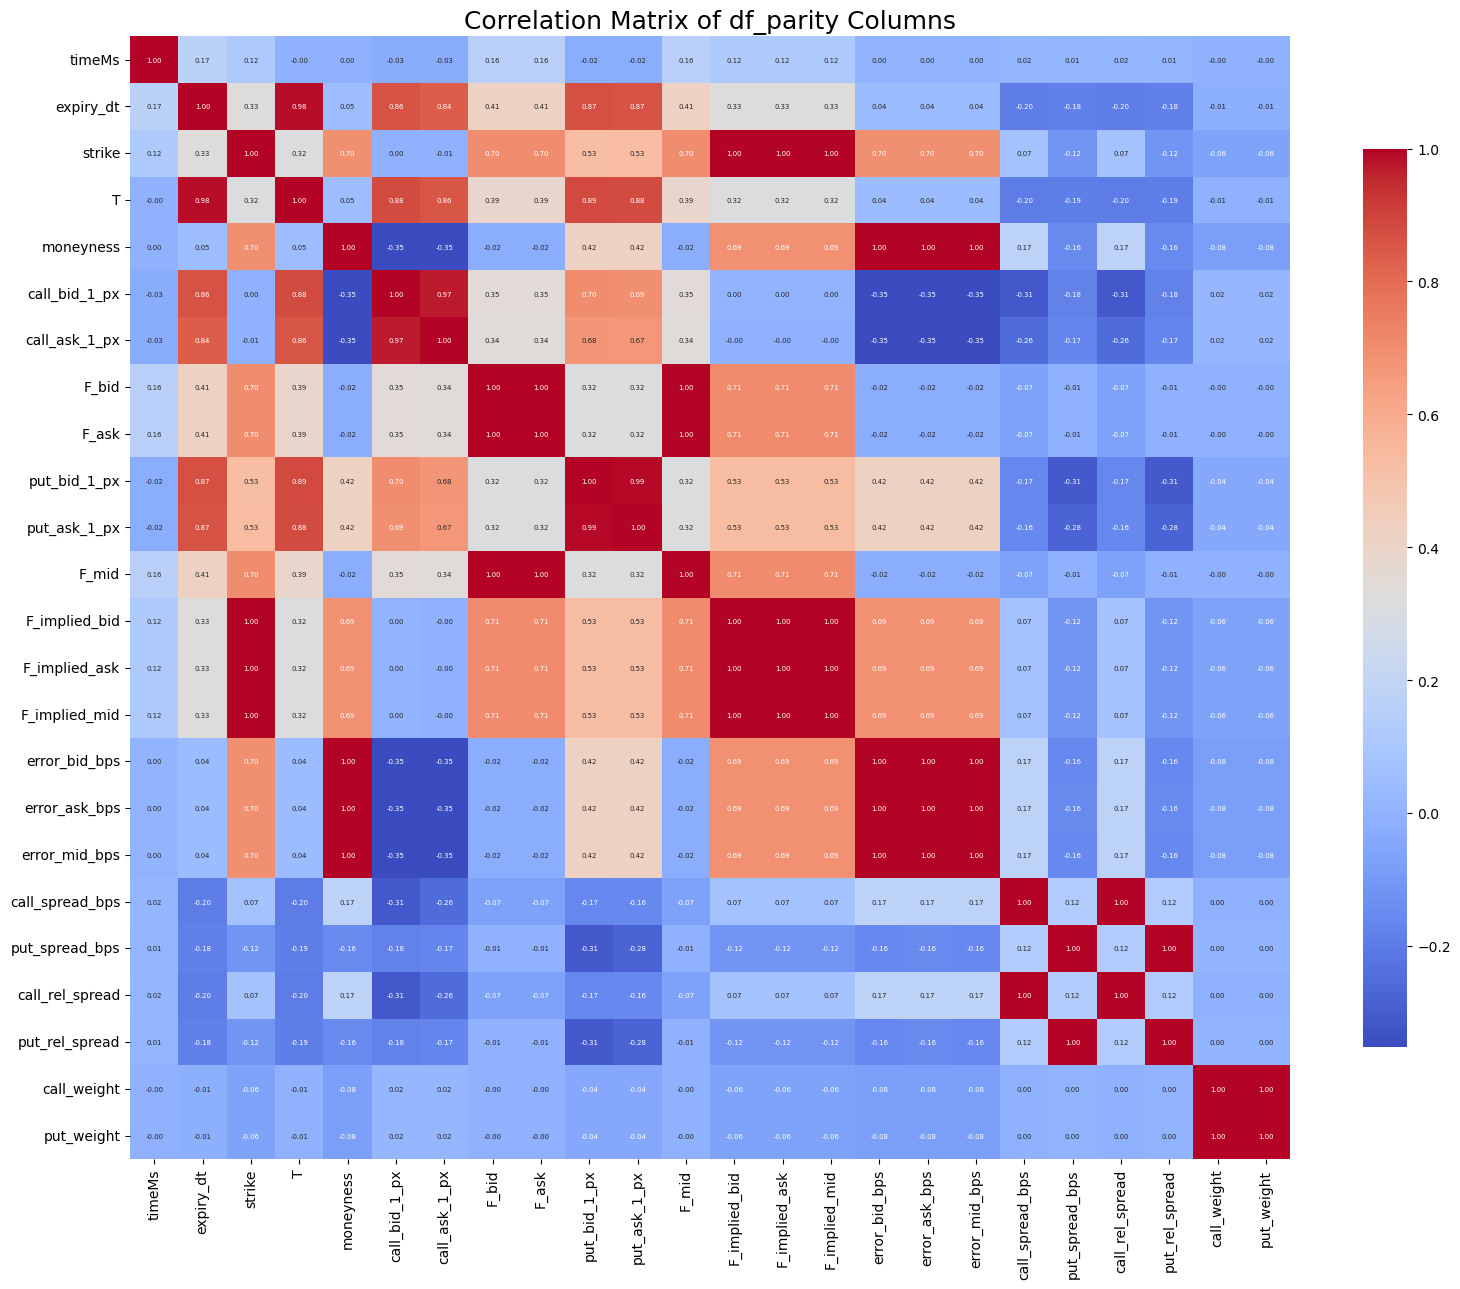

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Covariance is NOT restricted to [0, 1]. Covariance values depend on the scale of the variables.
# Large numbers (e.g., 1e19) indicate either high magnitude columns or potential numerical issues.
# If you want to get a standardized measure between -1 and 1, use the correlation matrix instead.

# Compute the *correlation* matrix for all columns in df_parity, which is always between -1 and 1
corr_matrix = df_parity.to_pandas().corr()

plt.figure(figsize=(16, 13))  # increase plot size for readability
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 5},  # make the annotation text a bit smaller
    cbar_kws={'shrink': .8}
)
plt.title("Correlation Matrix of df_parity Columns", fontsize=18)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()
